# LightGBM (level/QLIKE, CV-ensembled, bi-weekly) vs log-HAR — 6y window, δ=0.999, MCS

Does a **LightGBM** gradient-boosted-tree model beat (or join) the best **log-HAR** specs? Same
protocol as the XGBoost study but with LightGBM as the learner (this notebook contains **no
XGBoost**). Every model uses a **6-year rolling window (1512 trading days)** and **geometric
recency decay δ=0.999**, scored by **QLIKE in levels** on the **same common OOS dates**.

**LightGBM protocol.** Trees need no log transform and the target need not be normal, so LightGBM
is built the native way:
- **Level target + custom QLIKE objective.** Forecast `f = exp(raw)` (log link → positivity);
  QLIKE `L = y/f − log(y/f) − 1` gives `grad = w·(1 − y/f)`, `hess = w·(y/f)`. No log target, **no
  Duan smearing** — it optimises the exact metric we score on.
- **Recency** enters via the weight `w = δ**age` **baked into grad/hess** (the tree analog of WLS).
- **Time-series walk-forward CV, 4 expanding folds** (strictly chronological: each fold trains on
  rows before its validation block — no shuffled K-fold, no leakage). Grid over the LightGBM leaf
  controls `(max_depth, num_leaves)` paired `{(2,4),(3,7),(4,15)}` × `min_data_in_leaf ∈ {20,50,100}`
  (9 configs), `learning_rate=0.05` fixed; **early stopping** (QLIKE on each fold's validation block)
  auto-tunes the tree count. **Hyperparameters are ensembled**: each fold picks its own best config,
  all four refit on the full window, forecast = **mean of the 4**.
- **Bi-weekly refit** — the ensemble is refit every 10 trading days and held fixed in between.

**HAR** stays daily-refit and vectorised (copied from `HAR_simpleOLS_3d_with_macro.ipynb`).

**Models (all 6y / δ=0.999):** `lgb_matched` (`[x_d,x_w,x_m,log_GVZ,macro]`), `lgb_rich`
(+`log_RV_crude,log_RV_ES`), `har_run18` (HAR+GVZ+macro), `har_run19` (+SPX), `har_run20` (+crude).

In [1]:
# ===========================================================================
# Cell 1 — Imports & data
# ===========================================================================
# macOS: the pip lightgbm wheel needs libomp.dylib. scikit-learn ships one in its .dylibs/;
# if the import fails we add that folder to lib_lightgbm.dylib's rpath once (self-healing,
# same trick the XGBoost notebook documents). No repo/system files are touched.
import importlib.util, os, subprocess, time, itertools

def _import_lightgbm():
    try:
        import lightgbm as lgb; return lgb
    except OSError:
        import sklearn
        sk  = os.path.join(os.path.dirname(sklearn.__file__), ".dylibs")
        lib = os.path.join(os.path.dirname(importlib.util.find_spec("lightgbm").origin),
                           "lib", "lib_lightgbm.dylib")
        subprocess.run(["install_name_tool", "-add_rpath", sk, lib], check=False)
        import lightgbm as lgb; return lgb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch.bootstrap import MCS
lgb = _import_lightgbm()

data = pd.read_parquet("merged_RV_GVZ_with_macro_event.parquet")
rv = data["RV_gold"].astype(float)

TRADING_DAYS = 252
WINDOW_YEARS = np.arange(1.0, 7.001, 0.25)                 # reference grid (defines common OOS)
WINDOWS = [int(round(yr * TRADING_DAYS)) for yr in WINDOW_YEARS]
WINDOW = 6 * TRADING_DAYS                                  # 1512 days = 6y
DELTA = 0.999                                             # geometric recency decay
REFIT_EVERY = 10                                          # bi-weekly refit (trading days)
EPS = 1e-6                                                 # QLIKE forecast floor

print(f"RV_gold: {len(rv)} obs, {rv.index.min().date()} .. {rv.index.max().date()}")
print(f"WINDOW={WINDOW} (6y), DELTA={DELTA}, REFIT_EVERY={REFIT_EVERY}, lightgbm {lgb.__version__}")

RV_gold: 4015 obs, 2010-06-08 .. 2026-05-29
WINDOW=1512 (6y), DELTA=0.999, REFIT_EVERY=10, lightgbm 4.6.0


In [2]:
# ===========================================================================
# Cell 2 — Build the design tables (mirror HAR_simpleOLS_3d_with_macro)
# ===========================================================================
for col in ["RV_gold", "GVZ_close", "RV_ES", "RV_crude"]:
    assert (data[col] > 0).all(), f"{col} has non-positive values; log undefined"

x = np.log(rv)

def build_log_design(extra_cols):
    df = pd.DataFrame(index=rv.index)
    df["x_d"] = x
    df["x_w"] = x.rolling(5).mean()
    df["x_m"] = x.rolling(22).mean()
    for name, series in extra_cols.items():
        df[name] = series.reindex(rv.index)
    df["y_log"]   = x.shift(-1)        # log(RV_{t+1})  (HAR target)
    df["y_level"] = rv.shift(-1)       # RV_{t+1} in levels (QLIKE / LightGBM target)
    return df.dropna()

log_gvz   = np.log(data["GVZ_close"])
log_spx   = np.log(data["RV_ES"])
log_crude = np.log(data["RV_crude"])
macro     = data["macro_event"].shift(-1).astype(float)   # day-(t+1) scheduled-release dummy

d_gvz_macro       = build_log_design({"log_GVZ": log_gvz, "macro": macro})
d_crude_gvz_macro = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude, "macro": macro})
d_spx_gvz_macro   = build_log_design({"log_GVZ": log_gvz, "log_RV_ES": log_spx, "macro": macro})
d_all_macro       = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude,
                                      "log_RV_ES": log_spx, "macro": macro})

for d in (d_crude_gvz_macro, d_spx_gvz_macro, d_all_macro):
    assert d_gvz_macro.index.equals(d.index)
print("Run 18  log+GVZ+macro        rows:", len(d_gvz_macro))
print("rich    log+crude+SPX+GVZ+macro cols:", list(d_all_macro.columns))

Run 18  log+GVZ+macro        rows: 3993
rich    log+crude+SPX+GVZ+macro cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_crude', 'log_RV_ES', 'macro', 'y_log', 'y_level']


In [3]:
# ===========================================================================
# Cell 3 — Shared helpers: recency weights, QLIKE, common-OOS start, HAR loss series
# ===========================================================================
START_DATE = d_gvz_macro.index[max(WINDOWS)]   # same OOS gate as the HAR surface notebook

def _recency_weights(n, delta):
    """Geometric recency weights: newest row weight 1, row `age` older -> delta**age,
    mean-1 normalised. delta=1.0 -> equal weights."""
    if delta >= 1.0:
        return np.ones(n)
    ages = np.arange(n)[::-1]
    w = delta ** ages
    return w * (n / w.sum())

def _qlike(actual, forecast, eps=EPS):
    f = np.maximum(forecast, eps)
    r = actual / f
    return r - np.log(r) - 1.0, int((forecast <= eps).sum())

def rolling_log_ols_loss_series(design, feat_cols, window=WINDOW, delta=DELTA, start_date=None):
    """Vectorised weighted-OLS log-HAR, per-day QLIKE (levels), date-indexed Series.
    Copied from HAR_simpleOLS_3d_with_macro.ipynb (daily refit, Duan smearing)."""
    if start_date is None:
        start_date = START_DATE
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    yl  = design["y_log"].to_numpy(); lvl = design["y_level"].to_numpy(); idx = design.index
    N, p = X.shape
    t_oos = np.arange(window, N)[idx[window:] >= start_date]; starts = t_oos - window
    Xwins = np.lib.stride_tricks.sliding_window_view(X, window, axis=0)[starts].transpose(0, 2, 1)
    ywins = np.lib.stride_tricks.sliding_window_view(yl, window)[starts]
    w  = _recency_weights(window, delta); sw = np.sqrt(w)
    Xs = Xwins * sw[None, :, None]; ys = ywins * sw[None, :]
    beta = np.linalg.solve(np.einsum("nwi,nwj->nij", Xs, Xs), np.einsum("nwi,nw->ni", Xs, ys))
    fitted = np.einsum("nwp,np->nw", Xwins, beta)
    smear = np.einsum("nw,w->n", np.exp(ywins - fitted), w) / w.sum()
    fc = np.exp(np.einsum("np,np->n", X[t_oos], beta)) * smear
    q, _ = _qlike(lvl[t_oos], fc)
    return pd.Series(q, index=idx[t_oos], name="qlike")

print(f"Common OOS start: {START_DATE.date()}  "
      f"({int((d_gvz_macro.index >= START_DATE).sum())} forecast days)")

Common OOS start: 2017-07-11  (2229 forecast days)


In [4]:
# ===========================================================================
# Cell 4 — HAR baselines (3 specs) at 6y / delta=0.999  (daily refit)
# ===========================================================================
har_specs = [
    ("har_run18", d_gvz_macro,       ["x_d", "x_w", "x_m", "log_GVZ", "macro"]),
    ("har_run19", d_spx_gvz_macro,   ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES", "macro"]),
    ("har_run20", d_crude_gvz_macro, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude", "macro"]),
]
har_losses = {name: rolling_log_ols_loss_series(d, f) for name, d, f in har_specs}
for name in har_losses:
    print(f"{name}: mean QLIKE = {har_losses[name].mean():.6f}  (n={len(har_losses[name])})")

har_run18: mean QLIKE = 0.027551  (n=2229)
har_run19: mean QLIKE = 0.027546  (n=2229)
har_run20: mean QLIKE = 0.027481  (n=2229)


In [5]:
# ===========================================================================
# Cell 5 — LightGBM: custom QLIKE objective + 4-fold walk-forward CV (ensembled) + early stopping
# ===========================================================================
# Forecast f = exp(raw) (raw = booster margin; log link guarantees f>0). QLIKE objective:
#   L = y/f - log(y/f) - 1  ->  grad = w*(1 - y/f),  hess = w*(y/f)   (w = recency weights),
# baked into grad/hess (recency applied exactly once). The window's weighted mean log(y) is the
# init_score (base margin); LightGBM's predict(raw_score=True) EXCLUDES init_score, so the
# forecast adds it back: f = exp(clip(m0 + predict)).
from concurrent.futures import ThreadPoolExecutor
MARGIN_CLIP = (-2.0, 8.0)        # exp -> ~[0.14, 2981]; RV levels are ~5..60
ESR, CAP = 30, 500               # early-stopping rounds, max trees
WF_EDGES = [0.20, 0.40, 0.60, 0.80, 1.00]   # 4 expanding (chronological) walk-forward folds
# Paired (max_depth, num_leaves) x min_data_in_leaf -> 9 configs; learning_rate fixed at 0.05.
DEPTH_LEAVES = [(2, 4), (3, 7), (4, 15)]
MIN_DATA     = [20, 50, 100]
GRID = [dict(max_depth=md, num_leaves=nl, min_data_in_leaf=mdl, learning_rate=0.05,
             feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
             verbosity=-1, num_threads=-1, seed=0)
        for (md, nl) in DEPTH_LEAVES for mdl in MIN_DATA]
# We reuse one binned Dataset per window across all 9 grid configs (fast); feature_pre_filter
# must be OFF so the smaller min_data_in_leaf values are honoured on the reused Dataset
# (otherwise LightGBM errors / silently keeps the construction-time min_data_in_leaf).
DS_PARAMS = {"feature_pre_filter": False}

def _make_obj(w):
    def obj(preds, ds):
        y = ds.get_label(); f = np.exp(np.clip(preds, *MARGIN_CLIP))
        return w * (1.0 - y / f), w * (y / f)
    return obj

def _qlike_feval(preds, ds):
    y = ds.get_label(); f = np.maximum(np.exp(np.clip(preds, *MARGIN_CLIP)), EPS)
    r = y / f
    return "qlike", float(np.mean(r - np.log(r) - 1.0)), False   # (name, value, is_higher_better)

def _fit_window(Xw, yw, delta, nthreads=-1):
    """4-fold walk-forward CV on one rolling window -> 4 per-fold-best boosters refit on the
    full window (each at its early-stopped best_iteration). Returns (boosters, init_margin).
    `nthreads` caps LightGBM's thread count (per-call override of the GRID's num_threads),
    so the two models can run concurrently without oversubscribing the cores."""
    n = len(Xw); w_full = _recency_weights(n, delta)
    edges = [int(round(f * n)) for f in WF_EDGES]
    folds = [(0, edges[k], edges[k + 1]) for k in range(4)]
    chosen = []
    for tr0, v0, v1 in folds:
        Xtr, ytr = Xw[tr0:v0], yw[tr0:v0]
        Xvl, yvl = Xw[v0:v1], yw[v0:v1]
        wtr = w_full[tr0:v0] * ((v0 - tr0) / w_full[tr0:v0].sum())   # mean-1 on the fold (fit only)
        m0 = np.average(np.log(ytr), weights=wtr)
        dtr = lgb.Dataset(Xtr, label=ytr, init_score=np.full(len(ytr), m0),
                          params=DS_PARAMS, free_raw_data=False)
        dvl = lgb.Dataset(Xvl, label=yvl, init_score=np.full(len(yvl), m0),
                          reference=dtr, params=DS_PARAMS, free_raw_data=False)
        fb = None
        for params in GRID:
            bst = lgb.train(dict(params, objective=_make_obj(wtr), num_threads=nthreads), dtr,
                            num_boost_round=CAP, valid_sets=[dvl], valid_names=["val"],
                            feval=_qlike_feval,
                            callbacks=[lgb.early_stopping(ESR, verbose=False), lgb.log_evaluation(0)])
            sc = bst.best_score["val"]["qlike"]
            if fb is None or sc < fb[0]:
                fb = (sc, params, bst.best_iteration)
        chosen.append(fb)
    # refit each fold-best config on the FULL window (recency weights; best_iteration trees)
    m0f = np.average(np.log(yw), weights=w_full)
    dall = lgb.Dataset(Xw, label=yw, init_score=np.full(n, m0f),
                       params=DS_PARAMS, free_raw_data=False)
    boosters = [lgb.train(dict(p, objective=_make_obj(w_full), num_threads=nthreads), dall,
                          num_boost_round=max(int(bi), 1), callbacks=[lgb.log_evaluation(0)])
                for (_, p, bi) in chosen]
    return boosters, m0f

def _predict_ens(boosters, m0f, Xrows):
    fs = [np.exp(np.clip(m0f + bst.predict(Xrows, raw_score=True), *MARGIN_CLIP)) for bst in boosters]
    return np.mean(fs, axis=0)

def rolling_lgb_cv_loss_series(design, feat_cols, window=WINDOW, delta=DELTA,
                               refit_every=REFIT_EVERY, start_date=None, label="", nthreads=-1):
    """Bi-weekly walk-forward: every `refit_every` days refit the 4-model CV ensemble on the
    trailing window and hold it fixed for the block. Returns (per-day QLIKE Series, mean gain
    importance DataFrame over all refit boosters). `nthreads` caps LightGBM's thread count."""
    if start_date is None:
        start_date = START_DATE
    Xall = design[feat_cols].to_numpy(); lvl = design["y_level"].to_numpy(); idx = design.index
    N = len(design)
    t_oos = np.arange(window, N)[idx[window:] >= start_date]
    fc = np.empty(len(t_oos)); imp_accum = np.zeros(len(feat_cols)); n_models = 0
    t0 = time.time()
    for p0 in range(0, len(t_oos), refit_every):
        r = t_oos[p0]                                   # refit origin
        boosters, m0f = _fit_window(Xall[r - window:r], lvl[r - window:r], delta, nthreads)
        block = t_oos[p0:p0 + refit_every]
        fc[p0:p0 + refit_every] = _predict_ens(boosters, m0f, Xall[block])
        for bst in boosters:                            # accumulate normalised gain importance
            v = bst.feature_importance(importance_type="gain").astype(float)
            if v.sum() > 0:
                imp_accum += v / v.sum(); n_models += 1
        if (p0 // refit_every + 1) % 50 == 0:
            print(f"  [{label}] refit {p0 // refit_every + 1}/{int(np.ceil(len(t_oos)/refit_every))}"
                  f"  ({time.time()-t0:.0f}s)")
    q, clip = _qlike(lvl[t_oos], fc)
    imp = pd.Series(imp_accum / max(n_models, 1), index=feat_cols, name=label).sort_values(ascending=False)
    print(f"[{label}] done: mean QLIKE={q.mean():.6f}  clipped={clip}  "
          f"refits={int(np.ceil(len(t_oos)/refit_every))}  elapsed={time.time()-t0:.0f}s")
    return pd.Series(q, index=idx[t_oos], name="qlike"), imp

feats_matched = ["x_d", "x_w", "x_m", "log_GVZ", "macro"]
feats_rich    = ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude", "log_RV_ES", "macro"]

# Run the two independent models concurrently. LightGBM's train() releases the GIL, so a
# thread pool gives real parallelism; 2 threads/model -> 4 cores used, 4 left spare.
PAR_THREADS = 2
_jobs = {
    "lgb_matched": (d_gvz_macro, feats_matched),
    "lgb_rich":    (d_all_macro, feats_rich),
}
with ThreadPoolExecutor(max_workers=2) as _ex:
    _fut = {name: _ex.submit(rolling_lgb_cv_loss_series, d, f, label=name, nthreads=PAR_THREADS)
            for name, (d, f) in _jobs.items()}
    lgb_matched, imp_matched = _fut["lgb_matched"].result()
    lgb_rich,    imp_rich    = _fut["lgb_rich"].result()

  [lgb_matched] refit 50/223  (50s)


  [lgb_rich] refit 50/223  (52s)


  [lgb_matched] refit 100/223  (109s)


  [lgb_rich] refit 100/223  (112s)


  [lgb_matched] refit 150/223  (151s)


  [lgb_rich] refit 150/223  (158s)


  [lgb_matched] refit 200/223  (199s)


  [lgb_rich] refit 200/223  (208s)


[lgb_matched] done: mean QLIKE=0.030364  clipped=0  refits=223  elapsed=224s


[lgb_rich] done: mean QLIKE=0.030401  clipped=0  refits=223  elapsed=230s


In [6]:
# ===========================================================================
# Cell 6 — Assemble aligned loss matrix, cache, summary
# ===========================================================================
losses = pd.DataFrame({
    "lgb_matched": lgb_matched, "lgb_rich": lgb_rich,
    "har_run18": har_losses["har_run18"], "har_run19": har_losses["har_run19"],
    "har_run20": har_losses["har_run20"],
})
assert losses.notna().all().all(), "misaligned OOS dates between models"
assert len(losses) == len(lgb_matched) > 0
losses.to_parquet("lgb_vs_har_losses_6y.parquet")
print(f"Aligned loss matrix: {losses.shape[0]} OOS days x {losses.shape[1]} models  "
      f"({losses.index.min().date()} .. {losses.index.max().date()})")
summary = losses.mean().sort_values().rename("mean_qlike").to_frame()
print("\nMean QLIKE by model (lower = better):")
print(summary.to_string())

Aligned loss matrix: 2229 OOS days x 5 models  (2017-07-11 .. 2026-05-28)

Mean QLIKE by model (lower = better):
             mean_qlike
har_run20      0.027481
har_run19      0.027546
har_run18      0.027551
lgb_matched    0.030364
lgb_rich       0.030401


In [7]:
# ===========================================================================
# Cell 7 — Model Confidence Set (Hansen, Lunde & Nason 2011)
# ===========================================================================
mcs = MCS(losses, size=0.05, reps=10000, block_size=None,
          method="R", bootstrap="stationary", seed=42)
mcs.compute()
pv = mcs.pvalues["Pvalue"]
mcs_results = (pd.DataFrame({"mean_qlike": losses.mean(), "mcs_pvalue": pv})
               .assign(in_mcs=lambda d: d["mcs_pvalue"] > 0.05)
               .sort_values("mean_qlike"))
mcs_results.to_parquet("mcs_lgb_vs_har_6y.parquet")
pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print("Model Confidence Set (size=0.05, reps=10000, stationary bootstrap):\n")
print(mcs_results.to_string())
print(f"\nBest: {mcs_results.index[0]}")
print(f"In 5% MCS: {list(mcs_results.index[mcs_results['in_mcs']])}")
print(f"Excluded:  {list(mcs_results.index[~mcs_results['in_mcs']])}")
mcs_results

Model Confidence Set (size=0.05, reps=10000, stationary bootstrap):

             mean_qlike  mcs_pvalue  in_mcs
har_run20      0.027481    1.000000    True
har_run19      0.027546    0.550000    True
har_run18      0.027551    0.550000    True
lgb_matched    0.030364    0.118100    True
lgb_rich       0.030401    0.116500    True

Best: har_run20
In 5% MCS: ['har_run20', 'har_run19', 'har_run18', 'lgb_matched', 'lgb_rich']
Excluded:  []


,mean_qlike,mcs_pvalue,in_mcs
har_run20,0.027481,1.000000,True
har_run19,0.027546,0.550000,True
har_run18,0.027551,0.550000,True
lgb_matched,0.030364,0.118100,True
lgb_rich,0.030401,0.116500,True


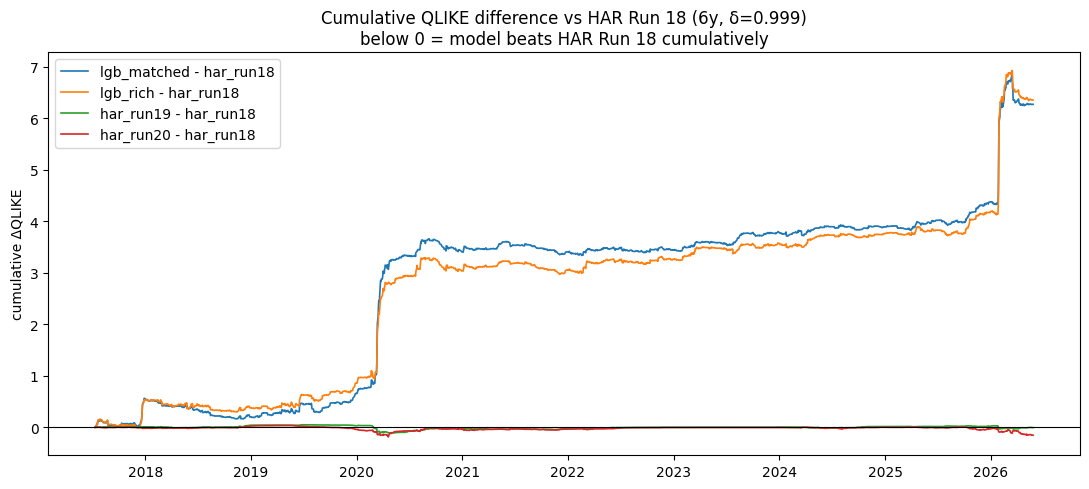

In [8]:
# ===========================================================================
# Cell 8 — Cumulative QLIKE difference vs HAR Run 18 (below 0 = model beats Run 18)
# ===========================================================================
fig, ax = plt.subplots(figsize=(11, 5))
for name, color in [("lgb_matched", "C0"), ("lgb_rich", "C1"),
                    ("har_run19", "C2"), ("har_run20", "C3")]:
    ax.plot(losses.index, (losses[name] - losses["har_run18"]).cumsum(),
            label=f"{name} - har_run18", color=color, lw=1.2)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Cumulative QLIKE difference vs HAR Run 18 (6y, δ=0.999)\n"
             "below 0 = model beats HAR Run 18 cumulatively")
ax.set_ylabel("cumulative ΔQLIKE"); ax.legend()
fig.tight_layout(); fig.savefig("lgb_vs_har_cum_qlike_6y.png", dpi=150); plt.show()

Mean normalised gain importance (NaN = feature absent from that model):
              lgb_matched  lgb_rich
log_GVZ          0.541462  0.567507
x_w              0.283405  0.235459
x_d              0.117779  0.111557
macro            0.031401  0.030111
x_m              0.025953  0.016823
log_RV_ES             NaN  0.025888
log_RV_crude          NaN  0.012655


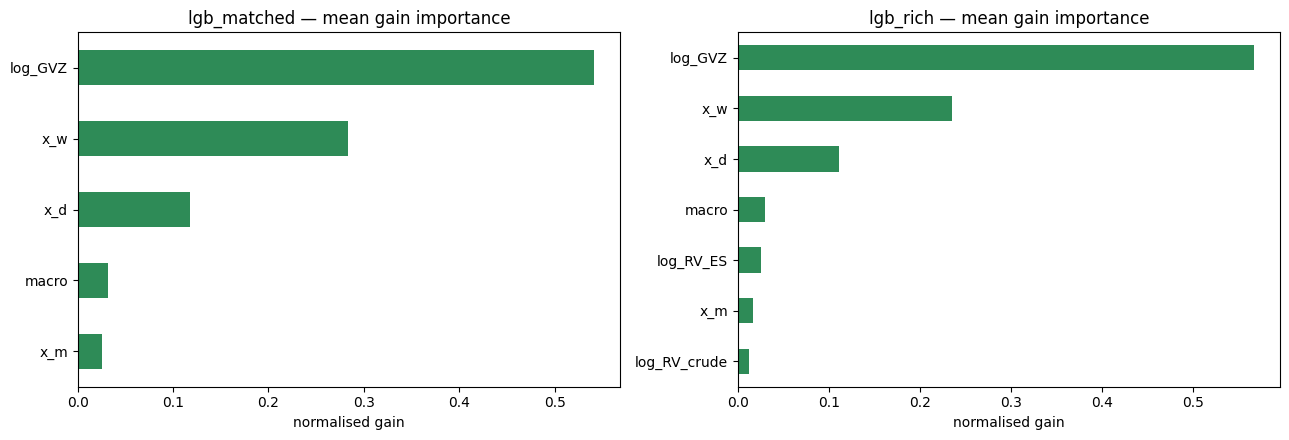

In [9]:
# ===========================================================================
# Cell 9 — LightGBM feature importance (mean gain across all bi-weekly refit boosters)
# ===========================================================================
imp = pd.concat([imp_matched.rename("lgb_matched"), imp_rich.rename("lgb_rich")], axis=1)
print("Mean normalised gain importance (NaN = feature absent from that model):")
print(imp.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, s, ttl in [(axes[0], imp_matched, "lgb_matched"), (axes[1], imp_rich, "lgb_rich")]:
    s.sort_values().plot.barh(ax=ax, color="seagreen")
    ax.set_title(f"{ttl} — mean gain importance"); ax.set_xlabel("normalised gain")
fig.tight_layout(); fig.savefig("lgb_feature_importance_6y.png", dpi=150); plt.show()